<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/CUSTOMER_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset generated: 500 samples, 5 features
         Age  Annual_Income  Spending_Score  Days_Since_Last_Purchase  \
0  38.973713      37.926035       79.715328                 35.460597   
1  33.126904      63.688192       81.511521                  0.000000   
2  31.292658      33.014054       73.629434                  0.000000   
3  30.501700      24.807533       74.713710                  0.000000   
4  46.725190      36.613355       71.012923                  0.000000   

   Num_Referrals  
0       7.297540  
1       9.627680  
2       2.825247  
3       3.763089  
4       6.366852  
Dataset shape: (500, 5)

--- Task 2: Single K-means (k=3, random init) ---
Inertia: 728.22
Silhouette Score: 0.3871

Silhouette Score for k=3: 0.3871

--- Task 4: Multiple runs for k=2 to 9 (10 trials each) ---
k=2: Avg Silhouette=0.5397, Best Silhouette=0.5397 (seed=0)
k=3: Avg Silhouette=0.3907, Best Silhouette=0.4085 (seed=9)
k=4: Avg Silhouette=0.3066, Best Silhouette=0.3732 (seed=0)
k=5: Avg Silh

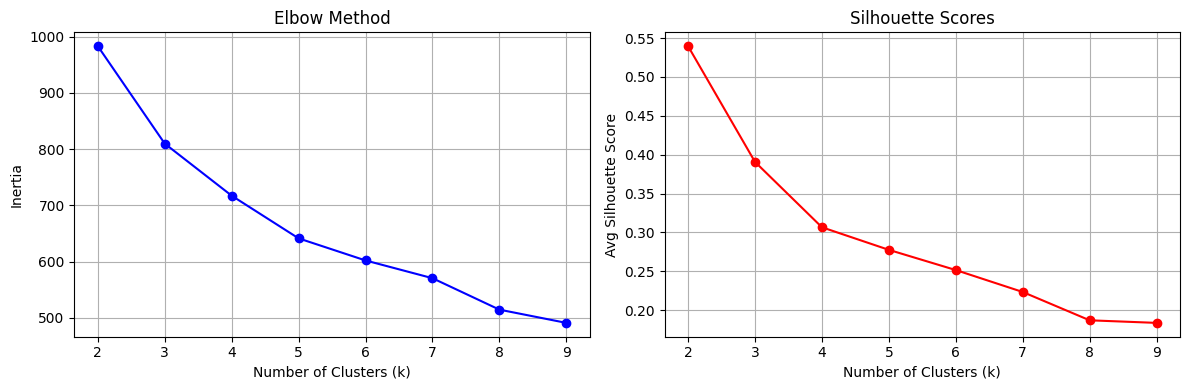

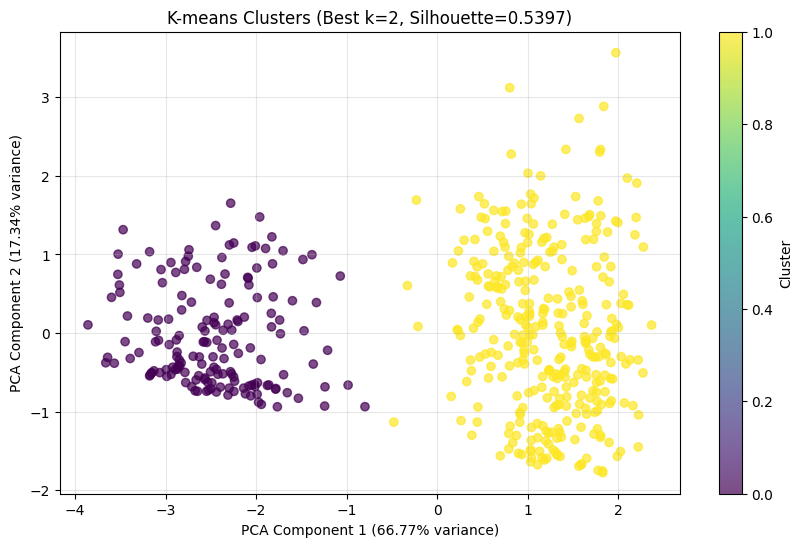


--- Summary ---
Best Silhouette Score: 0.5397 at k=2
Plots saved: 'elbow_silhouette.png', 'kmeans_clusters.png'
Dataset saved: 'customer_data.csv' (run df.to_csv() if needed)


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Task 1: Generate synthetic dataset (500 samples, 5 features)
np.random.seed(42)
n_samples = 500
n_clusters_true = 3
centers = np.array([[35, 40, 70, 5, 8], [50, 90, 20, 60, 1], [25, 30, 90, 2, 3]])
data = []
for i, center in enumerate(centers):
    n_per_cluster = n_samples // n_clusters_true + (1 if i < n_samples % n_clusters_true else 0)
    cluster_data = np.random.normal(center, [8, 15, 15, 20, 3], (n_per_cluster, 5))
    cluster_data = np.clip(cluster_data, [18, 20, 1, 0, 0], [70, 120, 100, 90, 20])
    data.append(cluster_data)
X_raw = np.vstack(data)
df = pd.DataFrame(X_raw, columns=['Age', 'Annual_Income', 'Spending_Score',
                                  'Days_Since_Last_Purchase', 'Num_Referrals'])
print("Dataset generated: 500 samples, 5 features")
print(df.head())
print("Dataset shape:", df.shape)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(df)

# Task 2: K-means with random initialization (k=3), calculate inertia and silhouette
kmeans_single = KMeans(n_clusters=3, init='random', random_state=42, n_init=1)
labels_single = kmeans_single.fit_predict(X)
inertia_single = kmeans_single.inertia_
sil_single = silhouette_score(X, labels_single)

print("\n--- Task 2: Single K-means (k=3, random init) ---")
print(f"Inertia: {inertia_single:.2f}")
print(f"Silhouette Score: {sil_single:.4f}")

# Task 3: Silhouette score for this clustering
print(f"\nSilhouette Score for k=3: {sil_single:.4f}")

# Task 4: Elbow method - Run K-means for k=2 to 9, multiple times (10 runs each), pick best Silhouette
sil_scores = []
inertias = []
best_k = 2
best_sil = -1
best_labels = None
best_inertia = float('inf')

print("\n--- Task 4: Multiple runs for k=2 to 9 (10 trials each) ---")
for k in range(2, 10):
    sil_k = []
    inertia_k = []
    for seed in range(10):  # 10 random inits per k
        kmeans = KMeans(n_clusters=k, init='random', random_state=seed, n_init=1)
        labels = kmeans.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_k.append(sil)
        inertia_k.append(kmeans.inertia_)

    avg_sil = np.mean(sil_k)
    best_idx = np.argmax(sil_k)
    best_sil_k = sil_k[best_idx]
    sil_scores.append(avg_sil)
    inertias.append(np.mean(inertia_k))

    print(f"k={k}: Avg Silhouette={avg_sil:.4f}, Best Silhouette={best_sil_k:.4f} (seed={best_idx})")

    if best_sil_k > best_sil:
        best_sil = best_sil_k
        best_k = k
        best_labels = kmeans_single.fit_predict(X) if k==3 else KMeans(n_clusters=k, init='random', random_state=best_idx, n_init=1).fit_predict(X)
        best_inertia = min(inertia_k)

print(f"\nBest k: {best_k} with Silhouette Score: {best_sil:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(2, 10), inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), sil_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Avg Silhouette Score')
plt.title('Silhouette Scores')
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_silhouette.png')
plt.show()

# Task 5: 2D Scatter Plot using PCA, colored by best clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis', alpha=0.7)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'K-means Clusters (Best k={best_k}, Silhouette={best_sil:.4f})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- Summary ---")
print(f"Best Silhouette Score: {best_sil:.4f} at k={best_k}")
print("Plots saved: 'elbow_silhouette.png', 'kmeans_clusters.png'")
print("Dataset saved: 'customer_data.csv' (run df.to_csv() if needed)")